In [1]:
import pandas as pd
import numpy as np
from openpyxl import Workbook
from datetime import datetime
from datetime import timedelta
from openpyxl.utils import get_column_letter
import datetime  
import pdb
import pandas as pd
import numpy as np 
# from pandas.io.json import json_normalize  
import json
# import psycopg2
from datetime import datetime
from dateutil.relativedelta import relativedelta
from urllib.parse import quote
from sqlalchemy.engine import create_engine
import warnings
from pandas import Timestamp
import dateutil
import pdb
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

# import mysql.connector
import pandas as pd
import numpy as np
from numpy import nan
import ast
from pandas import Timestamp
import pickle
import joblib
import openpyxl
from openpyxl import load_workbook
from openpyxl.utils import FORMULAE
import dateutil
import pdb
import datetime

import pdb
import pandas as pd
import numpy as np 
# from pandas.io.json import json_normalize  
from pandas import json_normalize
import json
import psycopg2
from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from urllib.parse import quote
from sqlalchemy.engine import create_engine
import warnings
warnings.filterwarnings("ignore")

from openpyxl import Workbook
from openpyxl.utils import get_column_letter
import pdb

warnings.filterwarnings("ignore")
three_months_ago = datetime.now() - relativedelta(months=2)
# C:\Users\saurabh.khopkar\Saurabh pythond code save path

In [2]:
# sas_config = r"C:\Users\mononita.mitra\OneDrive - UGRO Capital\Desktop\Mononita Data 14-09-2023\Mononita\GroMicro Login Analysis\config_ods.json"
# sas_config = r"C:\Users\saurabh.khopkar\Downloads\config_ods 2.json"
sas_config = r"C:\Users\saurabh.khopkar\Downloads\config_ods_Saurabh.json"
                
def connection_from_sas():
    try:
        f = open(sas_config)
        data = json.load(f)

 

        database = data.get("database")
        user = data.get("user")
        password = data.get("password")
        host = data.get("host")
        port = data.get("port")

 

        connection = psycopg2.connect(database=database, user=user, password=password, host=host, port=port)
        return connection

 

    except Exception as error:
        print(error)

In [3]:
connection = connection_from_sas()

In [4]:
sql_query_1 = """
select 
lob,laf_number,
cast(laf_creation_date as date) as laf_creation_date,
cast(pa_first_decision as date) as pa_first_decision,
cast(fa_first_decision as date) as fa_first_decision,
cast(mrk_for_disb_first_decision as date) as mrk_for_disb_first_decision,
login,pa_done_rank,pa_done,pa_ok_rank,pa_ok,fa_done_rank,fa_done,fa_ok_rank,fa_ok,mrk_for_disb_done,mrk_for_disb_done_rank,
prc_grp_disp_pa,prc_grp_disp_fa,prc_grp_disp_mrk_for_disb,
branch_name,c_branch_state,branch_type,region,micro_phase,
c_business_los,c_scheme_los,c_product_los,app_loan_amt,program_name,
solar_flg,login_month,lan,first_disb_date,no_of_disb,disb_status,disb_amt,
gp_name,gp_code,case_assigned_to_id,case_assigned_to_name,rm_id,rm_name,dsa_id,
dsa_name,case_allocated_id,case_allocated_name,credit_manager_id,credit_manager_name,
final_credit_manager_id,final_credit_manager_name,selectcreditmanagerid,
equipment_make,equipment_type,combo_flg,activitydescription,
cast(pa_start_date as date) as pa_start_date,
cast(pa_done_date as date) as pa_done_date,
cast(fa_start_date as date) as fa_start_date,
cast(fa_done_date as date) as fa_done_date,
partner_type,applicant_name,company_name,pan_number,gro_score,cast(go_live_date as date) as go_live_date
from login_summary_base_data lsbd
where lsbd.fa_first_decision  >= '2026-01-01'
or    lsbd.pa_first_decision  >= '2026-01-01'
"""
# cast(pa_first_decision as date) as pa_first_decision,
# select object_pri_key_1,equipment_make,equipment_type from collateral where equipment_make <>''
# and object_pri_key_1 in ('4FIN22050203550050840','4FIN220623033842642227','4FIN220720022010710305')
# where b.datetime_login >='2024-09-01'
# left join laf_detail_status b on a.object_pri_key_1=b.laf_number
# where b.datetime_login >='2024-09-01'

In [5]:
df1 = pd.read_sql_query(sql_query_1, connection)

In [6]:
df1.columns

Index(['lob', 'laf_number', 'laf_creation_date', 'pa_first_decision',
       'fa_first_decision', 'mrk_for_disb_first_decision', 'login',
       'pa_done_rank', 'pa_done', 'pa_ok_rank', 'pa_ok', 'fa_done_rank',
       'fa_done', 'fa_ok_rank', 'fa_ok', 'mrk_for_disb_done',
       'mrk_for_disb_done_rank', 'prc_grp_disp_pa', 'prc_grp_disp_fa',
       'prc_grp_disp_mrk_for_disb', 'branch_name', 'c_branch_state',
       'branch_type', 'region', 'micro_phase', 'c_business_los',
       'c_scheme_los', 'c_product_los', 'app_loan_amt', 'program_name',
       'solar_flg', 'login_month', 'lan', 'first_disb_date', 'no_of_disb',
       'disb_status', 'disb_amt', 'gp_name', 'gp_code', 'case_assigned_to_id',
       'case_assigned_to_name', 'rm_id', 'rm_name', 'dsa_id', 'dsa_name',
       'case_allocated_id', 'case_allocated_name', 'credit_manager_id',
       'credit_manager_name', 'final_credit_manager_id',
       'final_credit_manager_name', 'selectcreditmanagerid', 'equipment_make',
       'equipm

In [7]:
df1 = df1.sort_values("laf_number").drop_duplicates(["laf_number"], keep="first")

In [8]:
print (df1['pa_first_decision'].dtype)

object


In [9]:
df1.columns

Index(['lob', 'laf_number', 'laf_creation_date', 'pa_first_decision',
       'fa_first_decision', 'mrk_for_disb_first_decision', 'login',
       'pa_done_rank', 'pa_done', 'pa_ok_rank', 'pa_ok', 'fa_done_rank',
       'fa_done', 'fa_ok_rank', 'fa_ok', 'mrk_for_disb_done',
       'mrk_for_disb_done_rank', 'prc_grp_disp_pa', 'prc_grp_disp_fa',
       'prc_grp_disp_mrk_for_disb', 'branch_name', 'c_branch_state',
       'branch_type', 'region', 'micro_phase', 'c_business_los',
       'c_scheme_los', 'c_product_los', 'app_loan_amt', 'program_name',
       'solar_flg', 'login_month', 'lan', 'first_disb_date', 'no_of_disb',
       'disb_status', 'disb_amt', 'gp_name', 'gp_code', 'case_assigned_to_id',
       'case_assigned_to_name', 'rm_id', 'rm_name', 'dsa_id', 'dsa_name',
       'case_allocated_id', 'case_allocated_name', 'credit_manager_id',
       'credit_manager_name', 'final_credit_manager_id',
       'final_credit_manager_name', 'selectcreditmanagerid', 'equipment_make',
       'equipm

In [10]:
# numeric = ['pa_done','pa_ok','fa_done','fa_ok','mrk_for_disb_done']
# for item in numeric:
#     df1[item] = pd.to_numeric(df1[item], errors='coerce')

In [11]:
df1['login'] = pd.to_numeric(df1['login'], errors='coerce')
df1['pa_done_rank'] = pd.to_numeric(df1['pa_done_rank'], errors='coerce')
df1['pa_ok_rank'] = pd.to_numeric(df1['pa_ok_rank'], errors='coerce')
df1['fa_done_rank'] = pd.to_numeric(df1['fa_done_rank'], errors='coerce')
df1['fa_ok_rank'] = pd.to_numeric(df1['fa_ok_rank'], errors='coerce')
df1['solar_flg'] = pd.to_numeric(df1['solar_flg'], errors='coerce')
df1['app_loan_amt'] = pd.to_numeric(df1['app_loan_amt'], errors='coerce')
df1['no_of_disb'] = pd.to_numeric(df1['no_of_disb'], errors='coerce')
df1['disb_amt'] = pd.to_numeric(df1['disb_amt'], errors='coerce')
df1['micro_phase'] = pd.to_numeric(df1['micro_phase'], errors='coerce')
df1['mrk_for_disb_done_rank'] = pd.to_numeric(df1['mrk_for_disb_done_rank'], errors='coerce')

df1['pa_done'] = pd.to_numeric(df1['pa_done'], errors='coerce')
df1['pa_ok'] = pd.to_numeric(df1['pa_ok'], errors='coerce')
df1['fa_done'] = pd.to_numeric(df1['fa_done'], errors='coerce')
df1['fa_ok'] = pd.to_numeric(df1['fa_ok'], errors='coerce')
# df1['mrk_for_disb_done'] = pd.to_numeric(df1['mrk_for_disb_done'], errors='coerce')

In [12]:
df1['app_loan_amt_Cr'] = df1['app_loan_amt']/10000000

In [13]:
df1['pa_day'] = pd.to_datetime(df1['pa_first_decision']).dt.day
df1['fa_day'] = pd.to_datetime(df1['fa_first_decision']).dt.day
df1['mrk_for_disb_day'] = pd.to_datetime(df1['mrk_for_disb_first_decision']).dt.day

# df1['pa_Month_num'] = pd.to_datetime(df1['pa_first_decision']).dt.month
# df1['fa_Month_num'] = pd.to_datetime(df1['fa_first_decision']).dt.month
# df1['fa_month'] = pd.to_datetime(df1['fa_first_decision']).dt.month
# df['end of quarter'] = df['date'] + pd.offsets.QuarterEnd(1)

In [14]:
# df1['last_date'] = df1['fa_first_decision'].dt.to_timestamp() + pd.offsets.MonthEnd()
# df1['PA_Mon'] = pd.to_datetime(df1['pa_first_decision']).dt.strftime('%Y-%m')
# df1['fA_Mon'] = pd.to_datetime(df1['fa_first_decision']).dt.strftime('%Y-%m')

In [15]:
# df1 = pd.concat([df1.iloc[:3], pd.DataFrame({'fa_first_decision': pd.date_range(start='1999-01-03 06:00:00', freq='H')}).iloc[1:], df.iloc[3:]])

# df1['fa_first_decision'] = df1['fa_first_decision'].replace(np.nan, '31-12-1999')
# df1['pa_first_decision'] = df1['fa_first_decision'].replace(np.nan, '31-12-1999')

# df1['fa_first_decision'] = df1['fa_first_decision'].to_numpy().astype('datetime64[M]')

In [16]:
# df1['fa_first_decision'].apply(str)
# df1['pa_first_decision'].apply(str)

# df1['fa_first_decision'] = df1['fa_first_decision'].astype(str)

# df1['fa_first_decision'] = pd.to_numeric(df1['fa_first_decision'], errors='coerce').fillna(0).astype(np.int64)

In [17]:
# df1['FAMonth'] = (df1['fa_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
# df1['FAMonth'] = pd.to_datetime(df1['FAMonth'])

# df1['PAMonth'] = (df1['pa_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
# df1['PAMonth'] = pd.to_datetime(df1['PAMonth'])


df1['fa_first_decision'] = pd.to_datetime(df1['fa_first_decision'])
df1['fa_first_decision'] = pd.to_datetime(df1['fa_first_decision'])
df1['FA_Month'] = (df1['fa_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
df1['FA_Month'] = pd.to_datetime(df1['FA_Month'])


df1['first_disb_date'] = pd.to_datetime(df1['first_disb_date'])
df1['first_disb_date'] = pd.to_datetime(df1['first_disb_date'])
df1['first_disb_Month'] = (df1['first_disb_date'] + pd.offsets.MonthEnd(0)).dt.date
df1['first_disb_Month'] = pd.to_datetime(df1['first_disb_Month'])


df1['pa_first_decision'] = pd.to_datetime(df1['pa_first_decision'])
df1['pa_first_decision'] = pd.to_datetime(df1['pa_first_decision'])
df1['PA_Month'] = (df1['pa_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
# df1['PA_Month1'] = (df1['pa_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
df1['PA_Month'] = pd.to_datetime(df1['PA_Month'])
# df1['PA_Text'] = pd.to_datetime(df1['pa_first_decision'], format='%b-%y')
df1['PA_Month1'] = df1['pa_first_decision'].dt.strftime('%b%y')


df1['laf_creation_date'] = pd.to_datetime(df1['laf_creation_date'])
df1['laf_creation_date'] = pd.to_datetime(df1['laf_creation_date'])
df1['login_Month'] = (df1['laf_creation_date'] + pd.offsets.MonthEnd(0)).dt.date
df1['login_Month'] = pd.to_datetime(df1['login_Month'])


df1['mrk_for_disb_first_decision'] = pd.to_datetime(df1['mrk_for_disb_first_decision'])
df1['mrk_for_disb_Month'] = (df1['mrk_for_disb_first_decision'] + pd.offsets.MonthEnd(0)).dt.date
df1['mrk_for_disb_Month'] = pd.to_datetime(df1['mrk_for_disb_Month'])

# df1['go_live_date'] = pd.to_datetime(df1['go_live_date'])


# df1 = df1.drop(columns=['FA_Date','PA_Date','login_Date'])

In [18]:
df161 = df1[(df1["laf_number"]=="BAIIJU25020401000121684")] #Filtering dataframe
neworder = ['laf_number','branch_name','PA_Month1']
df161=df161.reindex(columns=neworder)
df161

,laf_number,branch_name,PA_Month1


In [19]:
df1['DMS_lob'] = df1['lob']

In [20]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
     df1['lob'].isin(['Gro Micro Sales Secured','Sanjeevani Micro','Machinery Micro',
                      'Rooftop Solar Micro','Gro Micro Sales Unsecured'])  ,
#         df16['Micro_br'].isin([1]) & 
# # df16.loc[df16['Micro_br'].isin(['1']) & 
#         df16['schemedesc_x'].isin(['GRO-MICRO-UNSECURED','SBL - UNSECURED','MICRO UNSECURED BLI']),
        'lob']='Gro Micro'
    

In [21]:
df161 = df1[(df1["laf_number"]=="LCHU272320241114121532")] #Filtering dataframe
# neworder = ['lan','closuredate','future_principle']
# df162=df161.reindex(columns=neworder)
df161

,lob,laf_number,laf_creation_date,pa_first_decision,fa_first_decision,mrk_for_disb_first_decision,login,pa_done_rank,pa_done,pa_ok_rank,...,pa_day,fa_day,mrk_for_disb_day,FA_Month,first_disb_Month,PA_Month,PA_Month1,login_Month,mrk_for_disb_Month,DMS_lob


In [22]:
df1.columns

Index(['lob', 'laf_number', 'laf_creation_date', 'pa_first_decision',
       'fa_first_decision', 'mrk_for_disb_first_decision', 'login',
       'pa_done_rank', 'pa_done', 'pa_ok_rank', 'pa_ok', 'fa_done_rank',
       'fa_done', 'fa_ok_rank', 'fa_ok', 'mrk_for_disb_done',
       'mrk_for_disb_done_rank', 'prc_grp_disp_pa', 'prc_grp_disp_fa',
       'prc_grp_disp_mrk_for_disb', 'branch_name', 'c_branch_state',
       'branch_type', 'region', 'micro_phase', 'c_business_los',
       'c_scheme_los', 'c_product_los', 'app_loan_amt', 'program_name',
       'solar_flg', 'login_month', 'lan', 'first_disb_date', 'no_of_disb',
       'disb_status', 'disb_amt', 'gp_name', 'gp_code', 'case_assigned_to_id',
       'case_assigned_to_name', 'rm_id', 'rm_name', 'dsa_id', 'dsa_name',
       'case_allocated_id', 'case_allocated_name', 'credit_manager_id',
       'credit_manager_name', 'final_credit_manager_id',
       'final_credit_manager_name', 'selectcreditmanagerid', 'equipment_make',
       'equipm

In [23]:
# df1[['Name', 'City']] = df1[['Name', 'City']].fillna('')
# df1[['branch_name']] = df1[['branch_name']].fillna('NA')
df1.loc[df1['branch_name'].isin(['']),'branch_name']='NA'

In [24]:
# df161 = df1[(df1["laf_number"]=="BAIIJU25020401000121684")] #Filtering dataframe
neworder = ['laf_number','branch_name','PA_Month1']
df161=df161.reindex(columns=neworder)
df161

,laf_number,branch_name,PA_Month1


In [25]:
df1 = df1.sort_values(by=['branch_name', 'PA_Month'])
# BAIIJU25020401000121684


In [26]:
df1['br_concate'] = df1['branch_name'] + df1['PA_Month1']

In [27]:
mask = (
    (df1['laf_number'].str.contains('1','0'))  
       )
df1.loc[mask, 'Branch_count'] = 1

In [28]:
df161 = df1[(df1["laf_number"]=="LCHU235920250128160021")] #Filtering dataframe
neworder = ['laf_number','branch_name','PA_Month1','Branch_count','br_concate','app_amt_bucket','app_loan_amt']
df161=df161.reindex(columns=neworder)
df161

,laf_number,branch_name,PA_Month1,Branch_count,br_concate,app_amt_bucket,app_loan_amt


In [29]:
# # df0 = pd.read_excel(r"D:\Saurabh\Trend Charts Last 3 Months.xlsx", sheet_name="Login details") #reads the first sheet of your excel file

In [30]:
m = df1.groupby(['br_concate'])['Branch_count'].transform('idxmax')
df1['Monthwise_Unique_Br'] = df1['Branch_count'].where(df1.index == m, other = 0)

In [31]:
df1['app_amt_bucket'] = np.where(df1['laf_number'].notnull(), 0,0)

In [32]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['app_loan_amt']<=5000000 , 
        'app_amt_bucket']="<=50"

In [33]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['app_loan_amt']>5000000 , 
        'app_amt_bucket']=">50"

In [34]:
# df1.to_excel(r"C:\Users\saurabh.khopkar\Downloads\logins_Anurag.xlsx", index=False)
# df161.to_excel(r"C:\Users\saurabh.khopkar\Downloads\Data.xlsx", index=False)


In [35]:
# zsm = pd.read_excel(r"‪D:\Saurabh\S3 Bucket file\Branch wise ZSM.xlsx", sheet_name="zsm") #reads the first sheet of your excel file
# zsm = pd.read_excel(r"‪D:\Saurabh\S3 Bucket file\branch_code_state_mapping.xlsx") #reads the first sheet of your excel file
# ZSM = pd.read_excel(r"‪D:\Saurabh\S3 Bucket file\Branch wise ZSM.xlsx","zsm")

# df = pd.read_excel('‪D:\Saurabh\S3 Bucket file\branch_code_state_mapping.xlsx')
zsm = pd.read_excel(r"D:\Saurabh\S3 Bucket file\Branch wise ZSM.xlsx", sheet_name='zsm')

In [36]:
zsm1 = zsm.rename(columns={'branch_name': 'branchdesc'})

In [37]:
neworder = ['branchdesc','ZSM']
zsm1=zsm1.reindex(columns=neworder)

In [38]:
zsm1

,branchdesc,ZSM
0,Agra Prime,Suruchi Sharma
1,Ahmedabad,Gunjan Kumar
2,Bangalore,Ashok Mariappan
3,Baroda Prime,Gunjan Kumar
4,Bhopal Prime,Gunjan Kumar
5,Chandigarh,Suruchi Sharma
6,Chennai,Ashok Mariappan
7,Coimbatore Prime,Ashok Mariappan
8,Delhi,Suruchi Sharma
9,Hubli Prime,Ashok Mariappan


In [39]:
df1=pd.merge(df1,zsm,on='branch_name',how='left')

In [40]:
df1.columns

Index(['lob', 'laf_number', 'laf_creation_date', 'pa_first_decision',
       'fa_first_decision', 'mrk_for_disb_first_decision', 'login',
       'pa_done_rank', 'pa_done', 'pa_ok_rank', 'pa_ok', 'fa_done_rank',
       'fa_done', 'fa_ok_rank', 'fa_ok', 'mrk_for_disb_done',
       'mrk_for_disb_done_rank', 'prc_grp_disp_pa', 'prc_grp_disp_fa',
       'prc_grp_disp_mrk_for_disb', 'branch_name', 'c_branch_state',
       'branch_type', 'region', 'micro_phase', 'c_business_los',
       'c_scheme_los', 'c_product_los', 'app_loan_amt', 'program_name',
       'solar_flg', 'login_month', 'lan', 'first_disb_date', 'no_of_disb',
       'disb_status', 'disb_amt', 'gp_name', 'gp_code', 'case_assigned_to_id',
       'case_assigned_to_name', 'rm_id', 'rm_name', 'dsa_id', 'dsa_name',
       'case_allocated_id', 'case_allocated_name', 'credit_manager_id',
       'credit_manager_name', 'final_credit_manager_id',
       'final_credit_manager_name', 'selectcreditmanagerid', 'equipment_make',
       'equipm

In [41]:
# df1.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df1.xlsx", index=False)

In [42]:
df1['Group_LOB'] = np.where(df1['lob'].notnull(),'NA',0)

In [43]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df16['Micro_br'].isin([1]) & 
        df1['lob'].isin(['Branch Secured Sales','Branch Unsecured Sales',
                          'Plant and Machinery Intermediary Distribution','Rooftop Solar Intermediate']),
        'Group_LOB']="Intermediated_channel"

In [44]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df16['Micro_br'].isin([1]) & 
        df1['lob'].isin(['Machinery Ecosystem Business','Rooftop Solar Ecosystem Business','Small Machinery Loan']),
        'Group_LOB']="Ecosystem_Business"

In [45]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df16['Micro_br'].isin([1]) & 
        df1['lob'].str.contains('Micro') | df1['lob'].str.contains('Emerging'),
        'Group_LOB']="Emerging_Market"

In [46]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df16['Micro_br'].isin([1]) & 
        df1['lob'].isin(['Partnership and Alliances RE']),
        'Group_LOB']="Partnerships_and_Alliances"

In [47]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df1['c_product_los'].isin(['Unsecured']) & 
        df1['c_business_los'].isin(['Branch']),
        'Group_LOB']="Intermediated_channel"

In [48]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df1['c_product_los'].isin(['Unsecured']) & 
        df1['c_business_los'].isin(['Gro Micro']),
        'Group_LOB']="Emerging_Market"

In [49]:
df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['Group_LOB'].isin(['NA']) & 
        # df1['c_product_los'].isin(['Unsecured']) & 
        df1['c_business_los'].isin(['Machinery']),
        'Group_LOB']="Ecosystem_Business"

In [50]:
df1['Group_LOB'].unique()

array(['Emerging_Market', 'Intermediated_channel', 'Ecosystem_Business',
       'Partnerships_and_Alliances'], dtype=object)

In [51]:
# df1.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df1.xlsx", index=False)

In [52]:
df1['EM_classification'] = np.where(df1['lob'].notnull(),'NA',0)

df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['EM_classification'].isin(['NA']) & 
        # df1['c_product_los'].isin(['Unsecured']) & 
        df1['program_name'].isin(['HL','Micro Secured-Griha Unnati SAL-Cash Flow Statement','Micro Secured- Griha Lakshya SAL-Cash Flow Statement',
                                  'Micro Secured- Griha Lakshya SE-Cash Flow Statement','Micro Secured-Griha Unnati SE-Cash Flow Statement']),
        'EM_classification']="EM_Home_Loan"

df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['EM_classification'].isin(['NA']) & 
        df1['lob'].isin(['Gro Micro']) & 
        df1['app_amt_bucket'].isin(['<=50']),
        'EM_classification']="EM_Secured_Upto_50L"

df1.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df1['EM_classification'].isin(['NA']) & 
        df1['lob'].isin(['Gro Micro']) & 
        df1['app_amt_bucket'].isin(['>50']),
        'EM_classification']="EM_Sanjeevani_secured"

In [53]:
# df1['pa_eom'] = df1['pa_first_decision'] + pd.offsets.MonthEnd(1)
# df1['fa_eom'] = df1['fa_first_decision'] + pd.offsets.MonthEnd(1)


In [54]:
sql_query_2 = """

select 
lob_1,lan,disb_date,disb_amt,disb_status,status,
initcap(branchdesc) as branchdesc,
disbursement_tenure,
branch_state as disb_branch_state,
login_branch_state,
c_business,c_scheme,product_lob,
branch_type,laf_id,laf_creation_date,schemedesc,program_name, 
micro_phase,region,facility_id,solar_flg,disbursement_roi,
processing_fee,subvention_payout ,sanctioned_amount,disb_month,login_month,customername,applicant_name,
gro_partner_name,gro_partner_code,case_assigned_to_id,case_assigned_to_name,
rm_id,rm_name,dsa_id,dsa_name,case_allocated_id,case_allocated_user_name,
closuredate,pan_no,industry,purpose_of_loan,equipment_make,equipment_type,
combo_flg,activitydescription,lds_branch,unique_lan,cast(go_live_date as date) as go_live_date,net_insurance,gross_insurance
from disb_summary_base_data dsbd
where dsbd.disb_date >='2026-01-01' and dsbd.disb_status in ('Partial Disbursed','Fully Disbursed','Pre Closed')
"""

# where dsbd.disb_date >='2024-09-29' and dsbd.disb_status in ('Partial Disbursed','Fully Disbursed','Pre Closed')

In [55]:
df2 = pd.read_sql_query(sql_query_2, connection)

In [56]:
laf_app_amt = """
select lds.laf_number as laf_id,lds.applied_loan_amt from laf_detail_status lds 
"""

In [57]:
laf_app_amt = pd.read_sql_query(laf_app_amt, connection)

In [58]:
laf_app_amt['applied_loan_amt'] = pd.to_numeric(laf_app_amt['applied_loan_amt'], errors='coerce')

In [59]:
df2=pd.merge(df2,laf_app_amt,on='laf_id',how='left')

In [60]:
df2['app_amt_bucket'] = np.where(df2['laf_id'].notnull(), 0,0)

In [61]:
# df2.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2.xlsx", index=False)

In [62]:
df2.loc[
        df2['applied_loan_amt']<=5000000 , 
        'app_amt_bucket']="<=50"

In [63]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df2['applied_loan_amt']>5000000 , 
        'app_amt_bucket']=">50"

In [64]:
df2['EM_classification'] = np.where(df2['lob_1'].notnull(),'NA',0)

In [65]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df2['EM_classification'].isin(['NA']) & 
        # df1['c_product_los'].isin(['Unsecured']) & 
        df2['program_name'].isin(['HL','Micro Secured-Griha Unnati SAL-Cash Flow Statement','Micro Secured- Griha Lakshya SAL-Cash Flow Statement',
                                  'Micro Secured- Griha Lakshya SE-Cash Flow Statement','Micro Secured-Griha Unnati SE-Cash Flow Statement']),
        'EM_classification']="EM_Home_Loan"

In [66]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df2['EM_classification'].isin(['NA']) & 
        df2['branch_type'].isin(['Micro']) & 
        df2['app_amt_bucket'].isin(['<=50']),
        'EM_classification']="EM_Secured_Upto_50L"

In [67]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df2['EM_classification'].isin(['NA']) & 
        df2['branch_type'].isin(['Micro']) & 
        df2['app_amt_bucket'].isin(['>50']),
        'EM_classification']="EM_Sanjeevani_secured"

In [68]:
# df2.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2.xlsx", index=False)

In [69]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [70]:
df2 = df2.sort_values("lan").drop_duplicates(["lan","disb_date","disb_amt"], keep="first")

In [71]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [72]:
# df2 = df2.sort_values(by=['lan', 'disb_date'], ascending=[True, False]) # true means asending false means desending 
df2 = df2.sort_values(by=['lan', 'disb_date'])

In [73]:
mask = (
    (df2['lan'].str.contains('0'))  
#         (df7['activitydescription'].str.contains('Transmission of electric energy')) |
#         (df7['activitydescription'].str.contains('Electric power generation by hydroelectric power plants')) |
#         (df7['activitydescription'].str.contains('Treatment of waste water or sewer by means of physical, chemical or biological processes')) |
       )
df2.loc[mask, 'Disb_status'] = 1

In [74]:
m = df2.groupby(['lan'])['Disb_status'].transform('idxmax')
df2['Unique_lan_manual_logic'] = df2['Disb_status'].where(df2.index == m, other = 0)

In [75]:
df161 = df2[(df2["lan"]=="UGAGHMS0000086984")] #Filtering dataframe
neworder = ['lan','disb_date','Unique_lan']
df161=df161.reindex(columns=neworder)
df161

,lan,disb_date,Unique_lan


In [76]:
df2['disb_amt'] = pd.to_numeric(df2['disb_amt'], errors='coerce')

In [77]:
df2['disb_amt_Cr'] = df2['disb_amt']/10000000

In [78]:
# df2['net_processing_fee'] = df2['processing_fee']/1.18

In [79]:
df2['Disb_day'] = pd.to_datetime(df2['disb_date']).dt.day
df2['Disb_Month_Num'] = pd.to_datetime(df2['disb_date']).dt.month

In [80]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [81]:
# df2['disb_EOM_Date'] = pd.to_datetime(df2['disb_date'])
# df2['disb_EOM_Date'] = pd.to_datetime(df2['disb_EOM_Date'])
# df2['disb_Month'] = (df2['disb_EOM_Date'] + pd.offsets.MonthEnd(0)).dt.date
# df2['disb_Month'] = pd.to_datetime(df2['disb_Month'])

df2['disb_date'] = pd.to_datetime(df2['disb_date'])
df2['disb_date'] = pd.to_datetime(df2['disb_date'])
df2['disb_month'] = (df2['disb_date'] + pd.offsets.MonthEnd(0)).dt.date
df2['disb_month'] = pd.to_datetime(df2['disb_month'])

In [82]:
# df2['Disb_day'] = pd.to_datetime(df2['disb_date']).dt.day
# df2 = df2.drop(columns=['disb_Month'])

In [83]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [84]:
# df2['Disb_day'] = pd.to_datetime(df2['disb_date']).dt.day
cols = ['Disb_day','solar_flg','processing_fee','disbursement_roi','facility_id','subvention_payout','sanctioned_amount',
        'micro_phase','disbursement_tenure','net_insurance','gross_insurance']
df2[cols] = df2[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [85]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [86]:
df2['DMS_lob'] = df2['lob_1']

In [87]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
     df2['lob_1'].isin(['Gro Micro Sales Secured','Sanjeevani Micro','Machinery Micro',
                      'Rooftop Solar Micro','Gro Micro Sales Unsecured'])  ,
#         df16['Micro_br'].isin([1]) & 
# # df16.loc[df16['Micro_br'].isin(['1']) & 
#         df16['schemedesc_x'].isin(['GRO-MICRO-UNSECURED','SBL - UNSECURED','MICRO UNSECURED BLI']),
        'lob_1']='Gro Micro'

In [88]:
# cols = ['pa_done_rank','pa_ok_rank','fa_done_rank','fa_ok_rank','solar_flg','micro_phase','app_loan_amt']
# df1[cols] = df1[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [89]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [90]:
# df1A = df1[(df1["pa_first_decision"]=>'31-10-2024')]
# df1A = df1[(df1["fa_first_decision"]>='2024-11-01') | (df1["pa_first_decision"]>='2024-11-01') ]
# df1A = df1[df1[df1['pa_first_decision'].dt.date.astype(str) >= '2024-10-31']]

In [91]:
# df2['disb_date'] = pd.to_datetime(df2['disb_date'], dayfirst=True)
# df2.groupby([df2['disb_date'].dt.month_name()], sort=False).sum().eval('disb_amt_Cr')\
#   .plot(kind='bar')

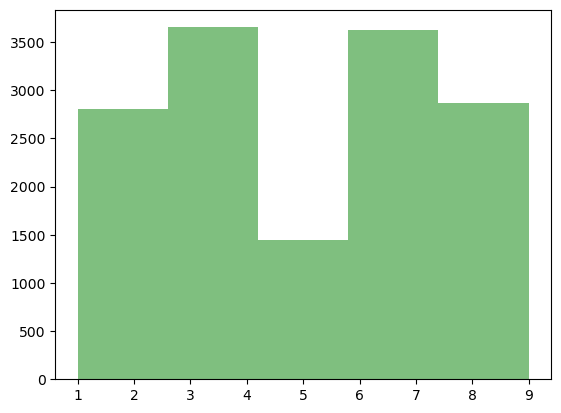

In [92]:
# x = [21,22,23,4,5,6,77,8,9,10,31,32,33,34,35,36,37,18,49,50,100]
num_bins = 5
n, bins, patches = plt.hist(df2.Disb_Month_Num, num_bins, facecolor='green', alpha=0.5)
plt.show()


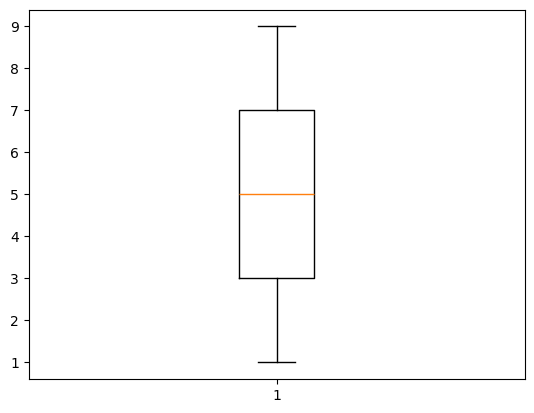

In [93]:
plt.boxplot(df2["Disb_Month_Num"])
plt.show()

In [94]:
df2['sanction_amt_bucket'] = np.where(df2['lan'].notnull(), 0,0)

In [95]:
df2.loc[
        df2['sanctioned_amount']<=5000000 , 
        'sanction_amt_bucket']="<=50"


In [96]:
df2.loc[
        df2['sanctioned_amount']>5000000 , 
        'sanction_amt_bucket']=">50"


In [97]:
df2.columns

Index(['lob_1', 'lan', 'disb_date', 'disb_amt', 'disb_status', 'status',
       'branchdesc', 'disbursement_tenure', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_id', 'laf_creation_date', 'schemedesc',
       'program_name', 'micro_phase', 'region', 'facility_id', 'solar_flg',
       'disbursement_roi', 'processing_fee', 'subvention_payout',
       'sanctioned_amount', 'disb_month', 'login_month', 'customername',
       'applicant_name', 'gro_partner_name', 'gro_partner_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_user_name',
       'closuredate', 'pan_no', 'industry', 'purpose_of_loan',
       'equipment_make', 'equipment_type', 'combo_flg', 'activitydescription',
       'lds_branch', 'unique_lan', 'go_live_date', 'net_insurance',
       'gross_insurance', 'applied_loan_amt', 'app_amt_bucket',
       'EM_classif

In [98]:
df2['Group_LOB'] = np.where(df2['lob_1'].notnull(),'NA',0)

In [99]:
df2.loc[
#     df26['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df26['Micro_br'].isin([1]) & 
        df2['lob_1'].isin(['Branch Secured Sales','Branch Unsecured Sales',
                          'Plant and Machinery Intermediary Distribution','Rooftop Solar Intermediate']),
        'Group_LOB']="Intermediated_channel"

In [100]:
df2.loc[
#     df26['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df26['Micro_br'].isin([1]) & 
        df2['c_business'].isin(['Branch']),
        'Group_LOB']="Intermediated_channel"

In [101]:
df2.loc[
#     df26['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df26['Micro_br'].isin([1]) & 
        df2['lob_1'].isin(['Machinery Ecosystem Business','Rooftop Solar Ecosystem Business','Small Machinery Loan']),
        'Group_LOB']="Ecosystem_Business"

In [102]:
df2.loc[
#     df26['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df26['Micro_br'].isin([1]) & 
        df2['c_business'].isin(['Machinery']),
        'Group_LOB']="Ecosystem_Business"

In [103]:
df2.loc[
#     df16['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df16['Micro_br'].isin([1]) & 
        df2['lob_1'].str.contains('Micro') | df2['lob_1'].str.contains('Emerging'),
        'Group_LOB']="Emerging_Market"

In [104]:
df2.loc[
#     df26['Foreclosure_LOB'].notnull() &
        df2['Group_LOB'].isin(['NA']) & 
        # df26['Micro_br'].isin([1]) & 
        df2['lob_1'].isin(['Partnership and Alliances RE']),
        'Group_LOB']="Partnerships_and_Alliances"

In [105]:
# df2.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2.xlsx", index=False)

In [106]:
OTC = pd.read_excel(r"D:\Saurabh\BIU\OCT cases\OTC Cases.xlsx","Sheet1")

In [107]:
df2=pd.merge(df2,OTC,on='lan',how='left')

In [108]:
neworder = ['lob','laf_number','lan','laf_creation_date','pa_first_decision','fa_first_decision','mrk_for_disb_first_decision','login','pa_done_rank',
            'pa_ok_rank','fa_done_rank','fa_ok_rank','mrk_for_disb_done_rank','prc_grp_disp_pa','prc_grp_disp_fa','prc_grp_disp_mrk_for_disb','branch_name','c_branch_state',
            'branch_type','region','micro_phase','c_business_los','c_scheme_los','c_product_los','app_loan_amt',
            'app_loan_amt_Cr','program_name','solar_flg','login_month','first_disb_date','no_of_disb','disb_status',
            'disb_amt','gp_name','gp_code','case_assigned_to_id','case_assigned_to_name','rm_id','rm_name','dsa_id',
            'dsa_name','case_allocated_id','case_allocated_name','credit_manager_id','credit_manager_name',
            'final_credit_manager_id','final_credit_manager_name','selectcreditmanagerid','equipment_make','equipment_type',
            'combo_flg','activitydescription','pa_start_date','pa_done_date','fa_start_date','fa_done_date',
            'partner_type','applicant_name','company_name','pan_number','gro_score','pa_day','fa_day','mrk_for_disb_day','FA_Month',
            'PA_Month','mrk_for_disb_Month','login_Month','DMS_lob','first_disb_Month','Monthwise_Unique_Br','app_amt_bucket','ZSM','go_live_date',
            'pa_done','pa_ok','fa_done','fa_ok','Group_LOB','EM_classification']

In [109]:
# Login data
df1=df1.reindex(columns=neworder)

In [110]:
# df1.to_excel(r"C:\Users\saurabh.khopkar\Downloads\login.xlsx", index=False)

In [111]:
neworder = ['lob_1','lan','laf_id','disb_date','disb_amt','disb_amt_Cr','disb_status','status','branchdesc','disb_branch_state',
            'login_branch_state','c_business','c_scheme','product_lob','branch_type','laf_creation_date','schemedesc','program_name',
            'micro_phase','region','facility_id','solar_flg','disbursement_roi','disbursement_tenure','net_processing_fee','processing_fee','subvention_payout',
            'sanctioned_amount','disb_month','login_month','customername','applicant_name','gro_partner_name',
            'gro_partner_code','case_assigned_to_id','case_assigned_to_name','rm_id','rm_name','dsa_id','dsa_name',
            'case_allocated_id','case_allocated_user_name','closuredate','pan_no','industry','purpose_of_loan',
            'equipment_make','equipment_type','combo_flg','activitydescription','Disb_day','Disb_Month_Num','lob_2',
            'lds_branch','unique_lan','DMS_lob','sanction_amt_bucket','go_live_date','net_insurance','gross_insurance','Group_LOB','applied_loan_amt','app_amt_bucket','EM_classification','otc_month']

In [112]:
# disb data
df2=df2.reindex(columns=neworder)

In [113]:
import re
df2.loc[
    (df2['schemedesc'].isin(['Money Plus Buyout','JFL DA Buyout'])) ,
           # (df_result['lob_1'].isin(['Money Plus Buyout','JFL DA Buyout'])), 
        'lob_1']="Buy out"

In [114]:
df2.columns

Index(['lob_1', 'lan', 'laf_id', 'disb_date', 'disb_amt', 'disb_amt_Cr',
       'disb_status', 'status', 'branchdesc', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_creation_date', 'schemedesc', 'program_name',
       'micro_phase', 'region', 'facility_id', 'solar_flg', 'disbursement_roi',
       'disbursement_tenure', 'net_processing_fee', 'processing_fee',
       'subvention_payout', 'sanctioned_amount', 'disb_month', 'login_month',
       'customername', 'applicant_name', 'gro_partner_name',
       'gro_partner_code', 'case_assigned_to_id', 'case_assigned_to_name',
       'rm_id', 'rm_name', 'dsa_id', 'dsa_name', 'case_allocated_id',
       'case_allocated_user_name', 'closuredate', 'pan_no', 'industry',
       'purpose_of_loan', 'equipment_make', 'equipment_type', 'combo_flg',
       'activitydescription', 'Disb_day', 'Disb_Month_Num', 'lob_2',
       'lds_branch', 'unique_lan', 'DMS_lob', 'sanction_amt_bucket'

In [115]:
# df2.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2.xlsx", index=False)

In [116]:
# df161 = df4[(df4["lan"]=="UGBANMC0000064318")] #Filtering dataframe
# neworder = ['lan','lob_2']
# df161=df161.reindex(columns=neworder)
# df161

In [117]:
# sql_query_ins_dms = """
# 	select * from insurance_data id  
# 	where id.disb_date >='2026-01-01' 
# """

In [118]:
# df_ins_dms = pd.read_sql_query(sql_query_ins_dms, connection)

In [119]:
# df_ins_dms.columns

In [120]:
# df_ins_dms['DMS_lob'] = df_ins_dms['lob_1']

In [121]:
# df_ins_dms.loc[
# #     df16['Foreclosure_LOB'].notnull() &
#      df_ins_dms['lob_1'].isin(['Gro Micro Sales Secured','Sanjeevani Micro','Machinery Micro',
#                       'Rooftop Solar Micro','Gro Micro Sales Unsecured','Gro Micro Sales'])  ,
# #         df16['Micro_br'].isin([1]) & 
# # # df16.loc[df16['Micro_br'].isin(['1']) & 
# #         df16['schemedesc_x'].isin(['GRO-MICRO-UNSECURED','SBL - UNSECURED','MICRO UNSECURED BLI']),
#         'lob_1']='Gro Micro'

In [122]:
# neworder_ins_dms = ['lob_1','lan','laf_id','disb_date','disb_month','disbursement_amount','sanctioned_amount','agreementid',
#             'branchdesc','disb_branch_state','schemedesc','program_name','productdescription','productflag','c_business',
#             'c_scheme','product_lob','branch_type','laf_creation_date','micro_phase','region','status','status1',
#             'customername','loandesc','disbursement_roi','disbursement_tenure','liamt','giamt','gross_ins_pnb','net_ins_pnb','gross_ins_digit',
#             'net_ins_digit','gross_sbi_liamt','net_sbi_liamt','gross_sbi_giamt','net_sbi_giamt','gross_li_go_digit',
#             'net_li_go_digit','gross_ev','net_ev','riskcovry_gross_ins','riskcovry_net_ins','sme_tiny_gross_ins', 'sme_tiny_net_ins','gross_ins_digit_all',
#             'net_ins_digit_all','gross_ins_sbi_all','net_ins_sbi_all','gross_digit_gi_asset_care_machinery','net_digit_gi_asset_care_machinery','gross_digit_gi_commercial_property','net_digit_gi_commercial_property',
# 'gross_digit_gi_residential_property','net_digit_gi_residential_property','gross_digit_gi_solar','net_digit_gi_solar','gross_digit_gi_hospicash',
# 'nets_digit_gi_hospicash','gross_digit_gi_emi_protection','net_digit_gi_emi_protection','gross_sbig_residential_property',
# 'net_sbig_residential_property','net_ins_prem','gross_ins_prem','pfamt','gst',
#             'net_loan_amt','insurance_penetration','Partner','line_of_business','DMS_lob']

In [123]:
# neworder_ins_dms = ['lob_1','lan','laf_id','disb_date','disb_month','disbursement_amount','sanctioned_amount','agreementid','branchdesc',
#                     'branch_state','schemedesc','program_name','productdescription','productflag','c_business','c_scheme','product_lob','branch_type',
#                     'laf_creation_date','micro_phase','region','status','status1','customername','disbursement_roi','disbursement_tenure','liamt',
#                     'giamt','gross_ins_pnb','net_ins_pnb','gross_digit_general','net_digit_general','gross_sbi_life','net_sbi_life',
#                     'gross_sbi_general','net_sbi_general','gross_digit_life','net_digit_life','gross_digit_ev_insurance','net_digit_ev_insurance',
#                     'gross_riskcovry_wellness','net_riskcovry_wellness','gross_sme_tiny','net_sme_tiny','gross_digit_gi_asset_care_machinery',
#                     'net_digit_gi_asset_care_machinery','gross_digit_gi_commercial_property','net_digit_gi_commercial_property',
#                     'gross_digit_gi_residential_property','net_digit_gi_residential_property','gross_digit_gi_solar','net_digit_gi_solar',
#                     'gross_digit_gi_hospicash','nets_digit_gi_hospicash','gross_digit_gi_emi_protection','net_digit_gi_emi_protection',
#                     'gross_sbig_residential_property','net_sbig_residential_property','gross_digit_general_all','net_digit_general_all',
#                     'gross_ins_sbi_all','net_ins_sbi_all','net_ins_prem','gross_ins_prem','pfamt','gst','net_loan_amt','insurance_penetration',
#                     'line_of_business','DMS_lob','Group_LOB']

In [124]:
# neworder_ins_dms = ['lob_1','lan','laf_id','disb_date','disb_month','disbursement_amount','sanctioned_amount','agreementid',
#             'branchdesc','disb_branch_state','schemedesc','program_name','productdescription','productflag','c_business',
#             'c_scheme','product_lob','branch_type','laf_creation_date','micro_phase','region','status','status1',
#             'customername','loandesc','disbursement_roi','disbursement_tenure','liamt','giamt','gross_ins_pnb','net_ins_pnb','gross_ins_digit',
#             'net_ins_digit','gross_sbi_liamt','net_sbi_liamt','gross_sbi_giamt','net_sbi_giamt','gross_li_go_digit',
#             'net_li_go_digit','gross_ev','net_ev','riskcovry_gross_ins','riskcovry_net_ins','sme_tiny_gross_ins', 'sme_tiny_net_ins','gross_ins_digit_all',
#             'net_ins_digit_all','gross_ins_sbi_all','net_ins_sbi_all','gross_digit_gi_asset_care_machinery','net_digit_gi_asset_care_machinery','gross_digit_gi_commercial_property','net_digit_gi_commercial_property',
# 'gross_digit_gi_residential_property','net_digit_gi_residential_property','gross_digit_gi_solar','net_digit_gi_solar','gross_digit_gi_hospicash',
# 'nets_digit_gi_hospicash','gross_digit_gi_emi_protection','net_digit_gi_emi_protection','gross_sbig_residential_property',
# 'net_sbig_residential_property','net_ins_prem','gross_ins_prem','pfamt','gst',
#             'net_loan_amt','insurance_penetration','line_of_business','DMS_lob']

In [125]:
# df_ins_dms=df_ins_dms.reindex(columns=neworder_ins_dms)

In [126]:
# df_ins_dms.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df_ins_dms.xlsx", index=False)

In [127]:
# # Insurance data
# df_ins_dms=df_ins_dms.reindex(columns=neworder_ins_dms)

In [128]:
# df_ins_dms['Group_LOB'] = np.where(df_ins_dms['lob_1'].notnull(),'NA',0)

In [129]:
# df_ins_dms.loc[
# #     df_ins_dms6['Foreclosure_LOB'].notnull() &
#         df_ins_dms['Group_LOB'].isin(['NA']) & 
#         # df_ins_dms6['Micro_br'].isin([1]) & 
#         df_ins_dms['lob_1'].isin(['Branch Secured Sales','Branch Unsecured Sales',
#                           'Plant and Machinery Intermediary Distribution','Rooftop Solar Intermediate']),
#         'Group_LOB']="Intermediated_channel"

# df_ins_dms.loc[
# #     df_ins_dms6['Foreclosure_LOB'].notnull() &
#         df_ins_dms['Group_LOB'].isin(['NA']) & 
#         # df_ins_dms6['Micro_br'].isin([1]) & 
#         df_ins_dms['c_business'].isin(['Branch']),
#         'Group_LOB']="Intermediated_channel"

# df_ins_dms.loc[
# #     df_ins_dms6['Foreclosure_LOB'].notnull() &
#         df_ins_dms['Group_LOB'].isin(['NA']) & 
#         # df_ins_dms6['Micro_br'].isin([1]) & 
#         df_ins_dms['lob_1'].isin(['Machinery Ecosystem Business','Rooftop Solar Ecosystem Business','Small Machinery Loan']),
#         'Group_LOB']="Ecosystem_Business"

# df_ins_dms.loc[
# #     df16['Foreclosure_LOB'].notnull() &
#         df_ins_dms['Group_LOB'].isin(['NA']) & 
#         # df16['Micro_br'].isin([1]) & 
#         df_ins_dms['lob_1'].str.contains('Micro') | df_ins_dms['lob_1'].str.contains('Emerging'),
#         'Group_LOB']="Emerging_Market"

# df_ins_dms.loc[
# #     df_ins_dms6['Foreclosure_LOB'].notnull() &
#         df_ins_dms['Group_LOB'].isin(['NA']) & 
#         # df_ins_dms6['Micro_br'].isin([1]) & 
#         df_ins_dms['lob_1'].isin(['Partnership and Alliances RE']),
#         'Group_LOB']="Partnerships_and_Alliances"

In [130]:
# df2A=pd.merge(df2,df4Disb_ins,on='lan',how='left')
# df2A=pd.merge(df2,df_ins_dms,on='lan',how='left')
df2A=df2


In [131]:
df2A.columns

Index(['lob_1', 'lan', 'laf_id', 'disb_date', 'disb_amt', 'disb_amt_Cr',
       'disb_status', 'status', 'branchdesc', 'disb_branch_state',
       'login_branch_state', 'c_business', 'c_scheme', 'product_lob',
       'branch_type', 'laf_creation_date', 'schemedesc', 'program_name',
       'micro_phase', 'region', 'facility_id', 'solar_flg', 'disbursement_roi',
       'disbursement_tenure', 'net_processing_fee', 'processing_fee',
       'subvention_payout', 'sanctioned_amount', 'disb_month', 'login_month',
       'customername', 'applicant_name', 'gro_partner_name',
       'gro_partner_code', 'case_assigned_to_id', 'case_assigned_to_name',
       'rm_id', 'rm_name', 'dsa_id', 'dsa_name', 'case_allocated_id',
       'case_allocated_user_name', 'closuredate', 'pan_no', 'industry',
       'purpose_of_loan', 'equipment_make', 'equipment_type', 'combo_flg',
       'activitydescription', 'Disb_day', 'Disb_Month_Num', 'lob_2',
       'lds_branch', 'unique_lan', 'DMS_lob', 'sanction_amt_bucket'

In [132]:
# df2A.loc[df2A['unique_lan'].isin([0]),'net_Ins_prem']=0
# df2A.loc[df2A['unique_lan'].isin([0]),'gross_Ins_prem']=0

In [133]:
df2A=pd.merge(df2A,zsm1,on='branchdesc',how='left')

In [134]:
# df2A.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2A.xlsx", index=False)

In [135]:
df2A['wt_disb'] = df2A['disb_amt'] * df2A['disbursement_roi']

In [136]:
# otc.to_excel(r"D:\Saurabh\BIU\OCT cases\OTC Cases.xlsx", index=False)

In [137]:
neworder = ['lob_1','lan','laf_id','disb_date','disb_amt','disb_amt_Cr','disb_status','status','branchdesc','disb_branch_state',
            'login_branch_state','c_business','c_scheme','product_lob','branch_type','laf_creation_date','schemedesc','program_name',
            'micro_phase','region','facility_id','solar_flg','disbursement_roi','disbursement_tenure','processing_fee','subvention_payout',
            'sanctioned_amount','disb_month','login_month','customername','applicant_name','gro_partner_name',
            'gro_partner_code','case_assigned_to_id','case_assigned_to_name','rm_id','rm_name','dsa_id','dsa_name',
            'case_allocated_id','case_allocated_user_name','closuredate','pan_no','industry','purpose_of_loan',
            'equipment_make','equipment_type','combo_flg','activitydescription','Disb_day','Disb_Month_Num','lob_2',
            'lds_branch','unique_lan','DMS_lob','net_insurance','gross_insurance','sanction_amt_bucket','wt_disb','ZSM','go_live_date','Group_LOB','applied_loan_amt','app_amt_bucket','EM_classification','otc_month']

In [138]:
df2A=df2A.reindex(columns=neworder)

In [139]:
# df2A.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2A.xlsx", index=False)

In [140]:
# df2A.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2A.xlsx", index=False)

In [141]:
# neworder = ['lan','C_business', 'C_scheme', 'C_business1',
#        'line_of_business', 'Business_LOB', 'Product_LOB','New Format','Micro_br']

In [142]:
# df2A=df2

In [143]:
# df24 = df2A.sort_values("lan").drop_duplicates(["lan", "closuredate","future_principle"], keep="first")
# df24 = df2A.sort_values("lan").drop_duplicates(["lan"], keep="first")

In [144]:
# min(df1A['fa_first_decision'])
# max(df1A['pa_first_decision'])
# print (df1A.index.min())
# print (df1A.index.max())

In [145]:
    # df2A = df2[(df2["disb_date"]>="2024-11-01")]

In [146]:
# df2A.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df2A.xlsx", index=False)
# df1.to_excel(r"C:\Users\saurabh.khopkar\Downloads\df1.xlsx", index=False)
# path0 = r"C:\Users\saurabh.khopkar\Downloads\Trend_Login_Disb_Base.xlsx"

In [147]:
# writer = pd.ExcelWriter(path0, engine = 'xlsxwriter')

In [148]:
# df1A.to_excel(writer, sheet_name = "Login", index = False)

In [149]:
# df2A.to_excel(writer, sheet_name = "Disb", index = False)

In [150]:
# writer.close()

In [151]:
# sql_query_5 = """
# select * from digital_lending_base_data dlbd
# """

In [152]:
# df5 = pd.read_sql_query(sql_query_5, connection)

In [153]:
# df5 = df5.drop(columns=['pos1','pos2','pos3','pos4','pos5','created_by','edl_job_run','edl_created_at','edl_partition_by'])

In [154]:
# cols = ['sanction_limit','roi','pf','pos','partner_tag']
# df5[cols] = df5[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [155]:
# df5['brand_upload_date'] = pd.to_datetime(df5['brand_upload_date'], format='%d/%m/%Y')
# df5['loan_sanction_date'] = pd.to_datetime(df5['loan_sanction_date'], format='%d/%m/%Y')
# df5['loan_end_date'] = pd.to_datetime(df5['loan_end_date'], format='%d/%m/%Y')
# df5['limit_activation_date'] = pd.to_datetime(df5['limit_activation_date'], format='%d/%m/%Y')

# # df5['brand_upload_date'] = pd.to_datetime(df5['brand_upload_date'])
# # df5['loan_sanction_date'] = pd.to_datetime(df5['loan_sanction_date'])
# # df5['loan_end_date'] = pd.to_datetime(df5['loan_end_date'])
# # df5['limit_activation_date'] = pd.to_datetime(df5['limit_activation_date'])

In [156]:
# neworder = ['final_partner','los_id','loan_acc_no','product_type','masterprogram','program_name','program_type','anchor_name','borrowername','rm_name','status','substatus','approval_status','partner_name','line_of_business','partner_tag','brand_upload_date','loan_sanction_date','loan_end_date','limit_activation_date','sanction_limit','roi','pf','groscore','pos']

In [157]:
# df5=df5.reindex(columns=neworder)

In [158]:
# file_path = 'C:\\Users\\saurabh.khopkar\\Downloads\\'
# one_day_ago = datetime.now() - timedelta(days=1)
# cur_time = one_day_ago.strftime("%d-%m-%Y_%H-%M-%S")
# # cur_time = one_day_ago.strftime("%d_%B_%H-%M-%S")
# filename="Trend_Login_Disb_Base_Ason_" + str(cur_time) + ".xlsx"
# # df.to_excel(file_path + filename, index=False)

In [159]:
# sql_query_6 = """
#  select *
#  from disbursement_event de 
# where disbursal_date>='2026-01-01'
# """

In [160]:
# df6

In [161]:
# df6 = pd.read_sql_query(sql_query_6, connection)

In [162]:
# df6.columns

In [163]:
# df6['disb_date'] = pd.to_datetime(df6['disbursal_date'])
# df6['disb_Month'] = (df6['disb_date'] + pd.offsets.MonthEnd(0)).dt.date
# df6['disb_Month'] = pd.to_datetime(df6['disb_Month'])

In [164]:
# cols = ['lan','loan_id','sanction_amount','offbook_disbursals','gross_disbursals','net_disbursal','total_disbursals','roi','tenure_month','cibil_score','lenderid']
# df6[cols] = df6[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [165]:
# df6['disb_day'] = pd.to_datetime(df6['disb_date']).dt.day
# df6['disb_month_num'] = pd.to_datetime(df6['disb_date']).dt.month

In [166]:
# df6A = df6.drop(columns=['lenderid','product_code','bank_ref_no','disbursal_date','edl_job_run'])

In [167]:
# df6A['total_disb_amt_cr'] = df6A['total_disbursals']/10000000

In [168]:
# df6A['prartner'] = df6A['prartner'].str.capitalize()
# df6A['customer_name'] = df6A['customer_name'].str.capitalize()
# # # df6A
# # # def capitalize_columns(df6A, columns):
# # #     for column in columns:
# # # columns_to_capitalize = ['prartner', 'customer_name']
# # # df6A = capitalize_columns(df6A, columns_to_capitalize)

In [169]:
# neworder = ['prartner','lan','loan_id','lender','disb_date','offbook_disbursals','gross_disbursals','net_disbursal','total_disbursals',
#             'total_disb_amt_cr','customer_name','sanction_amount','roi','tenure_month','type','disb_Month','disb_day','disb_month_num']

In [170]:
# df6A=df6A.reindex(columns=neworder)

In [171]:
file_path = 'C:\\Users\\saurabh.khopkar\\Downloads\\'
one_day_ago = datetime.now() - timedelta(days=1)
# cur_time = one_day_ago.strftime("%d-%m-%Y_%H-%M-%S")
cur_time = one_day_ago.strftime("%d_%B")
filename="MIS_" + str(cur_time) + "_Disb.xlsx"
# df.to_excel(file_path + filename, index=False)

In [172]:
writer = pd.ExcelWriter(file_path + filename, engine = 'xlsxwriter')

In [173]:
df1.to_excel(writer, sheet_name = "Login", index = False)

In [174]:
# for column in df1:
#     column_length = max(df1[column].astype(str).map(len).max(), len(column))
#     col_idx = df1.columns.get_loc(column)
#     writer.sheets['Login'].set_column(col_idx, col_idx, column_length)

In [175]:
# df1.to_excel(writer, sheet_name = "Login", index = False,freeze_panes=(1, 0))

In [176]:
# for column in df1:
#     column_length = max(df1[column].astype(str).map(len).max(), len(column))
#     col_idx = df1.columns.get_loc(column)
#     writer.sheets['Login'].set_column(col_idx, col_idx, column_length)

In [177]:
df2A.to_excel(writer, sheet_name = "Disb", index = False)

In [178]:
# df2A.to_excel(writer, sheet_name = "Disb", index = False,freeze_panes=(1, 0))

In [179]:
# for column in df2A:
#     column_length = max(df2A[column].astype(str).map(len).max(), len(column))
#     col_idx = df2A.columns.get_loc(column)
#     writer.sheets['Disb'].set_column(col_idx, col_idx, column_length)

In [180]:
# df_ins_dms.to_excel(writer, sheet_name = "Insurance", index = False)

In [181]:
# df_ins_dms.to_excel(writer, sheet_name = "Insurance", index = False,freeze_panes=(1, 0))

In [182]:
# for column in df_ins_dms:
#     column_length = max(df_ins_dms[column].astype(str).map(len).max(), len(column))
#     col_idx = df_ins_dms.columns.get_loc(column)
#     writer.sheets['Insurance'].set_column(col_idx, col_idx, column_length)

In [183]:
# df5.to_excel(writer, sheet_name = "DL_POS", index = False,freeze_panes=(1, 0))
# df5.to_excel(writer, sheet_name = "DL_POS", index = False)

In [184]:
# for column in df5:
#     column_length = max(df5[column].astype(str).map(len).max(), len(column))
#     col_idx = df5.columns.get_loc(column)
#     writer.sheets['DL_POS'].set_column(col_idx, col_idx, column_length)

In [185]:
# # df6A.to_excel(writer, sheet_name = "Embedded_Finance", index = False,freeze_panes=(1, 0))
# df6A.to_excel(writer, sheet_name = "Embedded_Finance", index = False)

In [186]:
# for column in df6A:
#     column_length = max(df6A[column].astype(str).map(len).max(), len(column))
#     col_idx = df6A.columns.get_loc(column)
#     writer.sheets['Embedded_Finance'].set_column(col_idx, col_idx, column_length)

In [187]:
# df2.to_excel(r"C:\Users\saurabh.khopkar\Downloads\Trend_Login.xlsx", index=False)
# path0 = r"C:\Users\saurabh.khopkar\Downloads\Trend_Login_Disb_Base.xlsx"

In [188]:
# path0 = 'C:\\Users\\saurabh.khopkar\\Downloads\\'
# one_day_ago = datetime.now() - timedelta(days=1)
# cur_time = one_day_ago.strftime("%d-%m-%Y")
# filename="MIS_As_on_" + str(cur_time) + ".xlsx"
# df1.to_excel(path0 + filename, index=False)

In [189]:
# writer = pd.ExcelWriter(path0, engine = 'xlsxwriter')

In [190]:
# df1.to_excel(writer, sheet_name = "Login", index = False,freeze_panes=(1, 0))

In [191]:
df1["lob"].value_counts()

lob
Gro Micro                       34037
Partnership and Alliances RE     3447
Machinery Ecosystem Business     1507
Branch Unsecured Sales           1297
Branch Secured Sales              286
Rooftop Solar Intermediate         19
Name: count, dtype: int64

In [192]:
# df2.to_excel(writer, sheet_name = "Disb", index = False,freeze_panes=(1, 0))

In [193]:
df1.columns

Index(['lob', 'laf_number', 'lan', 'laf_creation_date', 'pa_first_decision',
       'fa_first_decision', 'mrk_for_disb_first_decision', 'login',
       'pa_done_rank', 'pa_ok_rank', 'fa_done_rank', 'fa_ok_rank',
       'mrk_for_disb_done_rank', 'prc_grp_disp_pa', 'prc_grp_disp_fa',
       'prc_grp_disp_mrk_for_disb', 'branch_name', 'c_branch_state',
       'branch_type', 'region', 'micro_phase', 'c_business_los',
       'c_scheme_los', 'c_product_los', 'app_loan_amt', 'app_loan_amt_Cr',
       'program_name', 'solar_flg', 'login_month', 'first_disb_date',
       'no_of_disb', 'disb_status', 'disb_amt', 'gp_name', 'gp_code',
       'case_assigned_to_id', 'case_assigned_to_name', 'rm_id', 'rm_name',
       'dsa_id', 'dsa_name', 'case_allocated_id', 'case_allocated_name',
       'credit_manager_id', 'credit_manager_name', 'final_credit_manager_id',
       'final_credit_manager_name', 'selectcreditmanagerid', 'equipment_make',
       'equipment_type', 'combo_flg', 'activitydescription', 'p

In [194]:
# # df1.groupby('lob').sum().plot(y='disb_amt_Cr', kind='bar')
# df1.groupby('lob').count().plot(y='laf_number', kind='bar')
# df1.groupby('lob').sum().plot(y='app_loan_amt', kind='bar')

In [195]:
# counts = df1["lob"].value_counts(dropna=False)
# counts.plot.pie(autopct='%1.1f%%', labels=['Branch Secured Sales','Branch Unsecured Sales','Direct And Cross Sell','Direct And Cross Sell Solar','Gro Micro','Machinery Ecosystem Business','Partnership and Alliances DL','Partnership and Alliances RE','Plant and Machinery Intermediary Distribution','Rooftop Solar Ecosystem Business','Rooftop Solar Intermediate','Small Machinery Loan'], shadow=True)

# plt.title('Login')

# plt.axis('equal')
# plt.show()

In [196]:
df2A["lob_1"].value_counts()

lob_1
Gro Micro                       10722
Partnership and Alliances RE     2138
Machinery Ecosystem Business      695
Buy out                           394
Branch Unsecured Sales            338
Branch Secured Sales              105
Rooftop Solar Intermediate          4
Structured Finance                  2
Name: count, dtype: int64

In [197]:
# counts = df2["lob_1"].value_counts(dropna=False)
# counts.plot.pie(autopct='%1.1f%%', labels=['Branch Secured Sales','Branch Unsecured Sales','Direct And Cross Sell','Gro Micro','Machinery Ecosystem Business','Partnership and Alliances DL','Partnership and Alliances RE','Plant and Machinery Intermediary Distribution','Rooftop Solar Ecosystem Business','Rooftop Solar Intermediate','Small Machinery Loan'], shadow=True)

# plt.title('disb')

# plt.axis('equal')
# plt.show()

In [198]:
# # df2.plot('lob_1', 'disb_amt_Cr', kind='bar')
# dfdisb=df2.groupby('lob_1').sum().plot(y='disb_amt_Cr', kind='bar')

In [199]:
# df2.pivot_table(values='disb_amt_Cr', columns='lob_1').plot()
# sns.lineplot(x='date',y='num, data=df2, hue='lob_1',palette='bright)

In [200]:
# df4.to_excel(writer, sheet_name = "Insurance", index = False,freeze_panes=(1, 0))

In [201]:
# df5.to_excel(writer, sheet_name = "DL_POS", index = False,freeze_panes=(1, 0))

In [202]:
# writer.sheets['Login','Disb','Insurance','DL_POS'].set_column(col_idx, col_idx, 15)

In [203]:
workbook = writer.book
worksheet = writer.sheets['Login']

In [204]:
workbook = writer.book
worksheet2 = writer.sheets['Disb']

In [205]:
# workbook = writer.book
# worksheet_ins_dms = writer.sheets['Insurance']

In [206]:
# workbook = writer.book
# worksheet5 = writer.sheets['DL_POS']

In [207]:
# workbook = writer.book
# worksheet6A = writer.sheets['Embedded_Finance']

In [208]:
# for i, col in enumerate(df1.columns):
#     width = max(df1[col].apply(lambda x: len(str(x))).max(), len(col))
#     worksheet.set_column(i, i, width)

In [209]:
# for i, col in enumerate(df2A.columns):
#     width = max(df2A[col].apply(lambda x: len(str(x))).max(), len(col))
#     worksheet2.set_column(i, i, width)

In [210]:
# for i, col in enumerate(df_ins_dms.columns):
#     width = max(df_ins_dms[col].apply(lambda x: len(str(x))).max(), len(col))
#     worksheet_ins_dms.set_column(i, i, width)

In [211]:
# for i, col in enumerate(df5.columns):
#     width = max(df5[col].apply(lambda x: len(str(x))).max(), len(col))
#     worksheet5.set_column(i, i, width)

In [212]:
# for i, col in enumerate(df6A.columns):
#     width = max(df6A[col].apply(lambda x: len(str(x))).max(), len(col))
#     worksheet6A.set_column(i, i, width)

In [213]:
writer.close()

In [214]:
# Machinery_Direct_Trend_Split_LOB

In [215]:
path = r"D:\Saurabh\Trend charts split\Machinery_Direct.xlsx"

In [216]:
# df0 = pd.read_excel(r"D:\Saurabh\Trend Charts Last 3 Months.xlsx", sheet_name="Login details") #reads the first sheet of your excel file
# df0 = df0[(df0["C_Business_LOB"]=="Branch") & (df0["Product_LOB"]=="Unsecured") & (df0["Login-FA-0"]>0)] #Filtering dataframe
# df1A = df1[(df1["C_Business_LOB"]=="SBL") & (df1["Login-FA-0"]>0) & (df1["Solar"]==0)] #Filtering dataframe
df1A = df1[(df1["lob"]=="Machinery Ecosystem Business")] #Filtering dataframe
# df0['Date'] = pd.to_datetime(df0['login_month']).dt.normalize()
# df2 = pd.DataFrame(df2)

In [217]:
# df = pd.read_excel(r"D:\Saurabh\Trend Charts Last 3 Months.xlsx", sheet_name="disb_base_data") #reads the first sheet of your excel file
# df = df[(df["Business_LOB"]=="Branch") & (df["Product_LOB"]=="Unsecured")] #Filtering dataframe
df2AA = df2A[(df2A["lob_1"]=="Machinery Ecosystem Business")] #Filtering dataframe
# df2A = df2[(df2["lob_1"]=="Machinery Ecosystem Business") & (df2["Solar"]==0)] #Filtering dataframe
# df1 = pd.DataFrame(df1)

In [218]:
writer = pd.ExcelWriter(path, engine = 'xlsxwriter')

In [219]:
df1A.to_excel(writer, sheet_name = "login_Details", index = False)

In [220]:
df2AA.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [221]:
writer.close()

In [222]:
# Machinery_Intermidiate_Trend_Split_LOB

In [223]:
# path1 = r"D:\Saurabh\Trend charts split\Machinery_Intermidiate.xlsx"

In [224]:
# df1B = df1[(df1["lob"]=="Plant and Machinery Intermediary Distribution")] #Filtering dataframe

In [225]:
# df2B = df2A[(df2A["lob_1"]=="Plant and Machinery Intermediary Distribution")] #Filtering dataframe

In [226]:
# writer = pd.ExcelWriter(path1, engine = 'xlsxwriter')

In [227]:
# df1B.to_excel(writer, sheet_name = "login_Details", index = False)

In [228]:
# df2B.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [229]:
# writer.close()

In [230]:
# Solar1_Trend_Split_LOB

In [231]:
# path3 = r"D:\Saurabh\Trend charts split\Solar_Panel.xlsx"

In [232]:
# df1C = df1[(df1["solar_flg"]==1)] #Filtering dataframe

In [233]:
# df2C = df2A[(df2A["solar_flg"]==1)] #Filtering dataframe

In [234]:
# writer = pd.ExcelWriter(path3, engine = 'xlsxwriter')

In [235]:
# df1C.to_excel(writer, sheet_name = "login_Details", index = False)

In [236]:
# df2C.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [237]:
# writer.close()

In [238]:
# Sanjeevani_SL_Trend_Split_LOB

In [239]:
# path4 = r"D:\Saurabh\Trend charts split\Prime Secured.xlsx"

In [240]:
# df1D = df1[(df1["lob"]=="Branch Secured Sales")] #Filtering dataframe

In [241]:
# df2D = df2A[(df2A["lob_1"]=="Branch Secured Sales")] #Filtering dataframe

In [242]:
# writer = pd.ExcelWriter(path4, engine = 'xlsxwriter')

In [243]:
# df1D.to_excel(writer, sheet_name = "login_Details", index = False)

In [244]:
# df2D.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [245]:
# writer.close()

In [246]:
# Sanjeevani_USL_Trend_Split_LOB

In [247]:
# path5 = r"D:\Saurabh\Trend charts split\Prime Unsecured.xlsx"

In [248]:
# df1E = df1[(df1["lob"]=="Branch Unsecured Sales")] #Filtering dataframe

In [249]:
# df2E = df2A[(df2A["lob_1"]=="Branch Unsecured Sales")] #Filtering dataframe

In [250]:
# writer = pd.ExcelWriter(path5, engine = 'xlsxwriter')

In [251]:
# df1E.to_excel(writer, sheet_name = "login_Details", index = False)

In [252]:
# df2E.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [253]:
# writer.close()

In [254]:
# Gro Micro

In [255]:
path6 = r"D:\Saurabh\Trend charts split\Emerging Market Business.xlsx"

In [256]:
df1F = df1[(df1["lob"]=="Gro Micro")] #Filtering dataframe

In [257]:
df2F = df2A[(df2A["lob_1"]=="Gro Micro")] #Filtering dataframe

In [258]:
writer = pd.ExcelWriter(path6, engine = 'xlsxwriter')

In [259]:
df1F.to_excel(writer, sheet_name = "login_Details", index = False)

In [260]:
df2F.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [261]:
writer.close()

In [262]:
# path6 = r"D:\Saurabh\Trend charts split\Small_Machinery_Loan.xlsx"

In [263]:
# df1F = df1[(df1["lob"]=="Small Machinery Loan")] #Filtering dataframe

In [264]:
# df2F = df2A[(df2A["lob_1"]=="Small Machinery Loan")] #Filtering dataframe

In [265]:
# writer = pd.ExcelWriter(path6, engine = 'xlsxwriter')

In [266]:
# df1F.to_excel(writer, sheet_name = "login_Details", index = False)

In [267]:
# df2F.to_excel(writer, sheet_name = "disb_base_data", index = False)

In [268]:
writer.close()

###### 